## Preprocessing and Feature Engineering Notebook

### Capstone Porject

#### Team Rho

##### *Brendan Collari and Casey Brookshire*

In [2]:


#preprocessing and feature engieering


import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)


#load data 

DATA = Path("/Users/brendan/Documents/DSE6214/Team-Rho-Capstone-Project/Data/processed/team_rho_state_year_prediction_dataset_FINAL.csv")  # adjust filename to match repo
df = pd.read_csv(DATA)

print(df.shape)
df.head()

(452, 13)


,State,Year,state_population,mental_health_admissions,admission_rate_per_100k,suicidal thoughts_lag1,suicide hotline_lag1,self harm_lag1,mental health crisis_lag1,suicide prevention_lag1,crisis hotline_lag1,psychiatric hospital_lag1,depression help_lag1
0,Alaska,2015,738430.0,2200.0,297.929391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,2016,742575.0,2150.0,289.533044,0.000000,0.000000,16.000000,0.0,9.250000,0.0,0.000000,0.000000
2,Alaska,2017,740983.0,2250.0,303.650691,0.000000,0.000000,6.333333,0.0,12.750000,0.0,0.000000,13.250000
3,Alaska,2018,736624.0,2350.0,319.023002,7.666667,24.333333,7.500000,0.0,3.666667,0.0,0.000000,6.416667
4,Alaska,2019,733603.0,2450.0,333.968100,0.000000,22.000000,0.000000,0.0,18.333333,0.0,8.333333,5.583333


In [3]:
#first remove source variable for engineered target beingadmission_rate_per_100k = mental_health_admissions / state_population * 100,000
# mental_health_admissions embedded in the target and excluded from the predictor set to avoid leakage.
# state_population is retained as a control variable despite also being part of the target formula

df = df.drop(columns=["mental_health_admissions"])
print(df.shape)
print(df.columns.tolist())

(452, 12)
['State', 'Year', 'state_population', 'admission_rate_per_100k', 'suicidal thoughts_lag1', 'suicide hotline_lag1', 'self harm_lag1', 'mental health crisis_lag1', 'suicide prevention_lag1', 'crisis hotline_lag1', 'psychiatric hospital_lag1', 'depression help_lag1']


In [4]:
#next test and train split using the optimal ratio which is 67 to 33 split 
#split is time-based for panel structure and prevent the model from training on information from future years.

train_years = [2014, 2015, 2016, 2017, 2018, 2019, 2020]
test_years = [2021, 2022, 2023]

train_df = df[df["Year"].isin(train_years)].copy()
test_df = df[df["Year"].isin(test_years)].copy()

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

Train shape: (319, 12), Test shape: (133, 12)


In [5]:
# next handle missing lag values 

#the missing rows correspond to each state's first surviving year in the panel
#both rows fall within the training set so can drop rather than impute 

print("Before:", train_df.shape)
train_df = train_df.dropna(subset=["suicidal thoughts_lag1"])
print("After:", train_df.shape)

Before: (319, 12)
After: (317, 12)


In [6]:
#nexttandardize predictors for PCA
#the 8 lagged Google Trends predictors are standardized before dimensionality reduction
#the scaler is fit on training data only and applied to test data using those same parameters
# state_population is not included here cause not necessary for PCA

from sklearn.preprocessing import StandardScaler

search_term_cols = [
    "suicidal thoughts_lag1", "suicide hotline_lag1", "self harm_lag1",
    "mental health crisis_lag1", "suicide prevention_lag1",
    "crisis hotline_lag1", "psychiatric hospital_lag1", "depression help_lag1"
]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[search_term_cols])
test_scaled = scaler.transform(test_df[search_term_cols])

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)
print("Train mean:", train_scaled.mean(axis=0).round(2))
print("Train SD:", train_scaled.std(axis=0).round(2))

Train scaled shape: (317, 8)
Test scaled shape: (133, 8)
Train mean: [ 0.  0.  0.  0.  0.  0. -0. -0.]
Train SD: [1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
#next PCA on standardized search-term predictors
#PCA is applied to reduce dimensionality among the 8 lagged Google Trends predictors 
#PCA is fit on training data only and applied to test data using that same fit

from sklearn.decomposition import PCA

pca = PCA()
train_pca = pca.fit_transform(train_scaled)
test_pca = pca.transform(test_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i}: {ev:.3f} explained | {cv:.3f} cumulative")

PC1: 0.663 explained | 0.663 cumulative
PC2: 0.140 explained | 0.803 cumulative
PC3: 0.106 explained | 0.909 cumulative
PC4: 0.026 explained | 0.934 cumulative
PC5: 0.021 explained | 0.956 cumulative
PC6: 0.019 explained | 0.975 cumulative
PC7: 0.015 explained | 0.990 cumulative
PC8: 0.010 explained | 1.000 cumulative


In [8]:
#next finalize PCA
#retaining 3 components captures 90.9% of variance with a clear elbow after PC3 

n_components = 3
pca_final = PCA(n_components=n_components)
train_pca_final = pca_final.fit_transform(train_scaled)
test_pca_final = pca_final.transform(test_scaled)

pca_cols = [f"search_PC{i+1}" for i in range(n_components)]
train_pca_df = pd.DataFrame(train_pca_final, columns=pca_cols, index=train_df.index)
test_pca_df = pd.DataFrame(test_pca_final, columns=pca_cols, index=test_df.index)

print(train_pca_df.shape, test_pca_df.shape)

(317, 3) (133, 3)


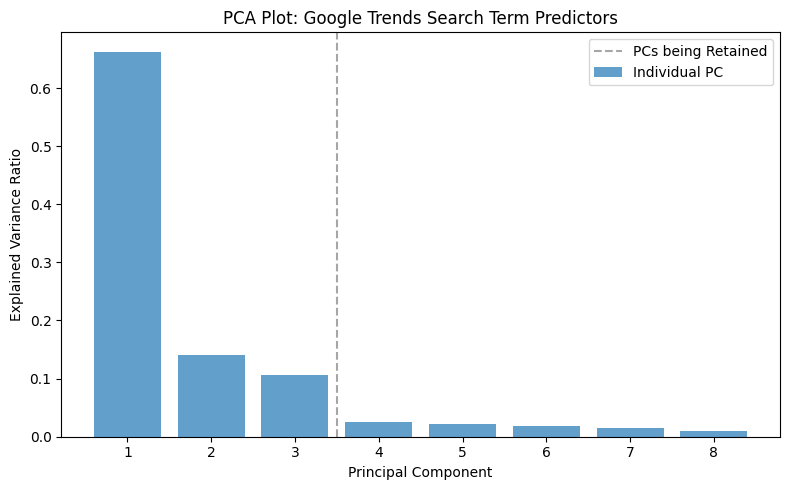

,PC1,PC2,PC3
suicidal thoughts_lag1,0.379,0.389,-0.028
suicide hotline_lag1,0.335,-0.393,-0.422
self harm_lag1,0.278,0.680,-0.056
mental health crisis_lag1,0.322,-0.284,0.557
suicide prevention_lag1,0.362,-0.297,-0.333
crisis hotline_lag1,0.343,-0.168,0.541
psychiatric hospital_lag1,0.399,0.177,0.108
depression help_lag1,0.394,-0.048,-0.304


In [15]:
#scree plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))
components = range(1, 9)
ax.bar(components, pca.explained_variance_ratio_, alpha=0.7, label='Individual PC')
ax.axvline(3.5, color='gray', linestyle='--', alpha=0.7, label='PCs being Retained')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Plot: Google Trends Search Term Predictors')
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/pca_scree_plot.png", dpi=150)
plt.show()

#loadings table
loadings = pd.DataFrame(pca.components_[:3].T, index=search_term_cols, columns=['PC1','PC2','PC3']).round(3)
loadings

In [10]:
#next assemble final preprocessed train/test datasets
#original 8 search term predictors are replaced with the 3 retained PCA components

keep_cols = ["State", "Year", "state_population", "admission_rate_per_100k"]

train_final = pd.concat(
    [train_df[keep_cols].reset_index(drop=True), train_pca_df.reset_index(drop=True)],
    axis=1
)
test_final = pd.concat(
    [test_df[keep_cols].reset_index(drop=True), test_pca_df.reset_index(drop=True)],
    axis=1
)

print("Train final shape:", train_final.shape)
print("Test final shape:", test_final.shape)
train_final.head()

Train final shape: (317, 7)
Test final shape: (133, 7)


,State,Year,state_population,admission_rate_per_100k,search_PC1,search_PC2,search_PC3
0,Alaska,2016,742575.0,289.533044,-4.113821,-0.244319,0.872428
1,Alaska,2017,740983.0,303.650691,-3.876032,-0.661745,0.603212
2,Alaska,2018,736624.0,319.023002,-3.754633,-0.741274,0.435839
3,Alaska,2019,733603.0,333.968100,-3.402270,-1.390120,0.099091
4,Alaska,2020,731158.0,348.761827,-3.302727,-1.491185,-0.055266


In [11]:
#next logtransform for state_population
#log-transformed version replaces the raw variable to avoid redundancy

train_final["log_state_population"] = np.log(train_final["state_population"])
test_final["log_state_population"] = np.log(test_final["state_population"])

train_final = train_final.drop(columns=["state_population"])
test_final = test_final.drop(columns=["state_population"])

print(train_final.shape, test_final.shape)
train_final.head()

(317, 7) (133, 7)


,State,Year,admission_rate_per_100k,search_PC1,search_PC2,search_PC3,log_state_population
0,Alaska,2016,289.533044,-4.113821,-0.244319,0.872428,13.517879
1,Alaska,2017,303.650691,-3.876032,-0.661745,0.603212,13.515733
2,Alaska,2018,319.023002,-3.754633,-0.741274,0.435839,13.509833
3,Alaska,2019,333.968100,-3.402270,-1.390120,0.099091,13.505723
4,Alaska,2020,348.761827,-3.302727,-1.491185,-0.055266,13.502385


In [12]:
#save train/test datasets

train_final.to_csv("team_rho_train_preprocessed.csv", index=False)
test_final.to_csv("team_rho_test_preprocessed.csv", index=False)

print("Saved.")

Saved.


In [ ]:
#done